In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# all distances are in Schwarzschild coordinates

In [3]:
# size of pixel
pixel_size = 0.1
# number of pixel in x direction
width_pixels = 40
# number of pixel in z direction
height_pixels = 30

# distance from observer to camera
d_obs_cam = 4
# distance from BH to camera
d_bh_cam = 10
# Schwarzschild radius, once r is smaller than this value, light can not get out of the horizon
r_s = 1

In [4]:
def get_init_xy(wi, hi):
    # position of the pixel
    xyz = np.array([
        -width_pixels * pixel_size / 2 + pixel_size / 2 + wi * pixel_size,
        -d_bh_cam,
        -height_pixels * pixel_size / 2 + pixel_size / 2 + hi * pixel_size,
    ])
    # position of the observer
    observer = np.array([0, -(d_obs_cam + d_bh_cam), 0])
    # direction of ray
    dxyzdl = xyz - observer
    dxyzdl = dxyzdl / np.linalg.norm(dxyzdl)
    
    # convert to 2D space
    e = -xyz[-1] / dxyzdl[-1]
    accretion = xyz + e * dxyzdl
    accretion = accretion / np.linalg.norm(accretion)
    if accretion[1] < 0:
        accretion = -accretion
    # accretion = np.array([0.0, 1.0, 0.0])
    
    x0 = np.dot(xyz, accretion)
    # TODO: when shall we use negative y0
    y0 = np.sqrt(np.dot(xyz, xyz) - x0**2)
    dxdl0 = np.dot(dxyzdl, accretion)
    # TODO: when shall we use negative dydl0
    dydl0 = np.sqrt(1 - dxdl0**2)
    return x0, y0, dxdl0, dydl0

def get_init_rphi(wi, hi):
    x0, y0, dxdl0, dydl0 = get_init_xy(wi, hi)
    r0 = np.hypot(x0, y0)
    phi0 = np.arctan2(y0, x0)
    drdl0 = drdl(x0, y0, dxdl0, dydl0)
    dphidl0 = dphidl(x0, y0, dxdl0, dydl0)
    u0 = drdl0
    L = r0**2 * dphidl0
    return r0, u0, phi0, L

In [5]:
def drdl(x, y, dxdl, dydl):
    return (x * dxdl + y * dydl) / np.hypot(x, y)

def dphidl(x, y, dxdl, dydl):
    return (x * dydl - y * dxdl) / (x*x + y*y)

In [6]:
def f(y, r_s, L):
    r, u, phi = y
    drdl = u
    dudl = (r - 1.5 * r_s) * (L**2 / r**4)
    dphidl = L / r**2
    return np.array([drdl, dudl, dphidl])

def rk4_step(y, dl, r_s, L):
    k1 = f(y, r_s, L)
    k2 = f(y + 0.5 * dl * k1, r_s, L)
    k3 = f(y + 0.5 * dl * k2, r_s, L)
    k4 = f(y + dl * k3, r_s, L)
    return y + (dl / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:03<00:00, 12.01it/s]


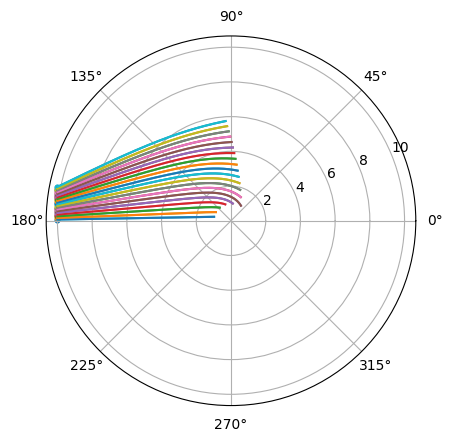

In [7]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

hi = height_pixels // 2
for wi in tqdm(range(width_pixels)):
    # for hi in range(height_pixels):
    r0, u0, phi0, L = get_init_rphi(wi, hi)
    
    y = np.array([r0, u0, phi0])
    
    dl = 1e-3
    N = int(1e4)
    trajectory = [y.copy()]
    
    for _ in range(N):
        y = rk4_step(y, dl, r_s, L)
        trajectory.append(y.copy())
        if y[0] <= r_s:
            break
    
    trajectory = np.array(trajectory)
    r_vals = trajectory[:, 0]
    phi_vals = trajectory[:, 2]
    ax.scatter(phi_vals[0], r_vals[0], s=10)
    ax.plot(phi_vals, r_vals)

plt.show()